This notebook shows how one can import data from zenodo and plot it alongside the data acquired.

In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import requests
import zipfile
import io
import scipy.io

HEADERS = {"User-Agent": "MyProject/1.0 (mailto:you@example.com)"}

url = "https://zenodo.org/records/7660668/files/Figure%201.zip?download=1"
r = requests.get(url, headers=HEADERS)

data = {}

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    mat_files = [n for n in z.namelist() if n.startswith("Figure 1d/") and n.endswith(".mat")]
    
    for name in mat_files:
        with z.open(name) as f:
            key = name.split("/")[-1]  # e.g. "hb_0field.mat"
            data[key] = scipy.io.loadmat(io.BytesIO(f.read()))

# Inspect contents
for filename, mat in data.items():
    keys = [k for k in mat.keys() if not k.startswith("_")]
    print(f"{filename}: {keys}")

hb_0field.mat: ['I', 'M', 'dp', 'energy', 'energy_max_zeroef', 'int_pl', 'int_range', 'power', 'None', 'spectra']
homobilayer_ef300_power_spectral.mat: ['ans', 'b_hbn_thick', 'd', 'dipole_moment', 'e_charge', 'energy', 'eps_0', 'eps_hbn', 'eps_tmdc', 'None', 'ii', 'index_2_sum', 'power', 'power_rounded', 'spectra', 'spectra_sum', 'spectra_sum_norm', 't_hbn_thick', 'u']
homobilayer_efm300_spectral.mat: ['I', 'M', 'd', 'energy', 'energy_max', 'None', 'int_pl', 'int_range', 'power', 'spectra']


c:\Users\Brandon\anaconda3\envs\viz-sci-plot\Lib\site-packages\scipy\io\matlab\_mio.py:236: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


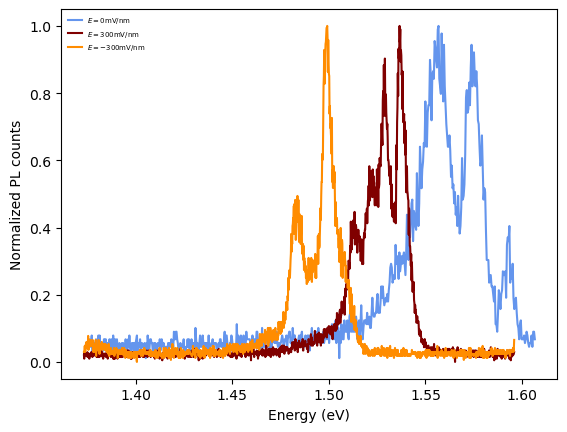

In [ ]:
hb_ef300 = data['homobilayer_ef300_power_spectral.mat']
hb_efm300 = data['homobilayer_efm300_spectral.mat']
hb_ef0 = data['hb_0field.mat']

hb_ef300_norm = (hb_ef300['spectra'][:,39] - np.min(hb_ef300['spectra'][:,39]))/(np.max(hb_ef300['spectra'][:,39]) - np.min(hb_ef300['spectra'][:,39]))
hb_efm300_norm = (hb_efm300['spectra'][:,39] - np.min(hb_efm300['spectra'][:,39]))/(np.max(hb_efm300['spectra'][:,39]) - np.min(hb_efm300['spectra'][:,39]))
hb_ef0_norm = (hb_ef0['spectra'][:,39] - np.min(hb_ef0['spectra'][:,39]))/(np.max(hb_ef0['spectra'][:,39]) - np.min(hb_ef0['spectra'][:,39]))

fig, ax = plt.subplots()
ax.plot(hb_ef0['energy'][290:-420], hb_ef0_norm[290:-420], color='cornflowerblue', linestyle='-', label='$E=0$mV/nm')
ax.plot(hb_ef300['energy'][10:-10], hb_ef300_norm[10:-10], color='maroon', linestyle='-', label='$E=300$mV/nm')
ax.plot(hb_efm300['energy'][10:-10], hb_efm300_norm[10:-10], color='darkorange', linestyle='-', label='$E=-300$mV/nm')

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Normalized PL counts')
ax.legend(loc='upper left', frameon=False, fontsize=5)